# DeepRV for Bayesian Inference on GPs
In this notebook, we use **DeepRV** to replace sampling from a Gaussian process.

Let $(s \in \mathbb{R}^n)$ denote a fixed set of input points, and let $(k_{\theta}(\cdot,\cdot))$ be a kernel function with parameters $(\theta)$. We assume
$$
f(s) \sim \mathcal{GP}(0, K_{\theta}),
\qquad
(K_{\theta})_{ij} = k_{\theta}(s_i, s_j).
$$

Equivalently, a draw from the Gaussian process can be written as

$$
f(s) = L_{\theta} z,
\qquad
z \sim \mathcal{N}(0, I_n),
\qquad
L_{\theta} = \mathrm{chol}(K_{\theta}).
$$

Since the Cholesky decomposition of an $(n \times n)$ matrix scales as $(O(n^3))$, we use trained neural network that provides a faster approximation:

$$
\mathrm{DeepRV}(\theta, z) \approx f(s).
$$

---
In general, the hierarchy is

$$
\theta \sim p(\theta),
$$

$$
f(s) \mid \theta \sim \mathcal{GP}(0, K_{\theta})

$$

$$
y \sim \mathrm{p}\left(\kappa\left(f(s)\right)\right),
$$

where $\kappa(\cdot)$ is the inverse link function. Note that there are no observations for the mesh points.

The target posterior is therefore

$$
p(\theta, f \mid y)
\propto
p(\theta), p(f \mid \theta), p(y \mid f, \theta).
$$

During inference, we draw samples from this posterior using HMC. At each iteration of HMC, given the current state $(\theta, f)$, we must evaluate the log posterior:

$$
\log p(\theta, f \mid y)
=

\log p(\theta)
+
\log p(f \mid \theta)
+
\log p(y \mid f, \theta).
$$

---
For the monocarp species, we have:

1. **Growth**
   $$
   f(z) \sim \mathcal{GP}(0, K)
   $$

2. **Flowering probability**
   $$
   p_f(z) = \sigma(f(z)), \qquad \text{Flowering}(z) \sim \mathrm{Bernoulli}(p_f(z))
   $$

3. **Survival probability**
   $$
   p_s(z) = \sigma(f(z)), \qquad \text{Survival}(z) \sim \mathrm{Bernoulli}(p_s(z))
   $$

4. **Seed production**
   $$
    \text{SeedProduction}(z) \sim \mathrm{Poisson}\!\bigl(\exp(f(z))\bigr)
   $$

5. **Recruit size**
   Since recruit size is independent of $z$, we use a fixed distribution, for example:
   $$
   z_1 \sim \mathcal{N}(\mu, \sigma)
   $$

6. **Recruitment Probability**
    $$
    \mathrm{Recruit} \sim \mathrm{Bernoulli}\!\bigl(p_{\mathrm{recr}}\bigr)    
    $$



In [1]:
import sys

sys.path.append("benchmarks/vae")
from functools import partial
from pathlib import Path
from typing import Callable, Optional, Union
import jax
from jax import Array, jit, random
import jax.numpy as jnp
from jax.scipy.linalg import solve_triangular
from jax.scipy.stats import norm
import time
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import optax
from numpyro import distributions as dist
import json
from hydra.utils import instantiate
import orbax


from numpyro.infer import MCMC, NUTS, Predictive, init_to_median
from dl4bi_sps.kernels import rbf
from dl4bi_sps.utils import build_grid
from utils.plot_utils import plot_infer_trace

import wandb
from dl4bi.core.model_output import VAEOutput
from dl4bi.core.train import cosine_annealing_lr, train
from dl4bi.vae import gMLPDeepRV
from dl4bi.vae.train_utils import deep_rv_train_step, generate_surrogate_decoder
from deeprv_utils import hmc, gen_train_dataloader, valid_step, train_deeprv, run_gp_inference, run_deeprv_inference, compute_metrics, load_saved_deeprv

/opt/anaconda3/envs/dl4bi-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
priors = {
    "ls": dist.HalfNormal(5.0), 
    "r": dist.HalfNormal(5.0),
    "obs_noise":dist.HalfNormal(5.0),
    "beta":dist.Normal(7.5,2.0)
    }

In [4]:
survival_priors = {
    "beta": dist.Normal(0.0, 1.25),
    "r": dist.HalfNormal(1.0),
    "ls": dist.LogNormal(jnp.log(1.0), 0.5),
}

In [5]:
reproduction_priors = {
    "beta": dist.Normal(-3.0, 1.0),
    "r": dist.LogNormal(jnp.log(0.5), 0.75),
    "ls": dist.LogNormal(jnp.log(1.0), 0.5),
}

In [6]:
seed_priors = {
    "beta": dist.Normal(7.4, 0.8),
    "r": dist.LogNormal(jnp.log(0.5), 0.75),
    "ls": dist.LogNormal(jnp.log(1.0), 0.5),
}

In [7]:
growth_priors = {
    "beta": dist.Normal(0.0, 1.25),
    "r": dist.LogNormal(jnp.log(0.5), 0.75),
    "ls": dist.LogNormal(jnp.log(1.0), 0.5),
    "obs_noise": dist.HalfNormal(1.0),
}

In [24]:
# Works for SEED LOL
priors = {
    "beta": dist.Normal(7.4, 0.6),
    "r": dist.LogNormal(jnp.log(0.5), 0.5),
    "ls": dist.LogNormal(jnp.log(0.7), 0.5),
}

In [8]:
sim_data = pd.read_csv("gp_sample250.csv")
sim_data.shape

(250, 8)

In [9]:
sim_data.head()

,id,year,z,z1,age,survived,reproduced,n_seeds
0,445141,39,1.068144,1.716993,2,1.0,0,NaN
1,110162,28,0.071170,NaN,0,0.0,0,NaN
2,266958,34,1.331782,2.654812,1,1.0,0,NaN
3,327160,35,-1.156128,NaN,0,0.0,0,NaN
4,367965,37,1.078800,NaN,1,0.0,0,NaN


In [10]:
sim_data.columns

Index(['id', 'year', 'z', 'z1', 'age', 'survived', 'reproduced', 'n_seeds'], dtype='object')

In [11]:
# Full location array in the original sim_data row order
s_all = jnp.asarray(
    sim_data["z"].to_numpy(dtype="float32")
)[:, None]

surv_mask = (
    (sim_data["reproduced"] == 0)
    & sim_data["z"].notna()
    & sim_data["survived"].notna()
)

surv_idx = np.flatnonzero(surv_mask.to_numpy(dtype=bool))
s_surv = s_all[surv_idx]
y_surv = jnp.asarray(sim_data.loc[surv_mask,"survived",].to_numpy(dtype="float32"))

print("Full locations:", s_all.shape)
print("s_surv:", s_surv.shape)
print("y_surv:", y_surv.shape)
print("surv_idx:", surv_idx.shape)

Full locations: (250, 1)
s_surv: (239, 1)
y_surv: (239,)
surv_idx: (239,)


In [12]:
# Reproduction data
repr_mask = (
    (sim_data["reproduced"].notna())
)

repr_idx = np.flatnonzero(repr_mask.to_numpy(dtype=bool))
s_repr = s_all[repr_idx]
y_repr = jnp.asarray(sim_data.loc[repr_mask,"reproduced"].to_numpy(dtype="float32"))

print("s_repr:", s_repr.shape)
print("y_repr:", y_repr.shape)
print("repr_idx:", repr_idx.shape)

s_repr: (250, 1)
y_repr: (250,)
repr_idx: (250,)


In [13]:
# Seed data
seed_mask = ((sim_data["reproduced"] == 1) & sim_data["z"].notna() & sim_data["n_seeds"].notna())


seed_idx = np.flatnonzero(seed_mask.to_numpy(dtype=bool))
s_seed = s_all[seed_idx]
y_seed = jnp.asarray(sim_data.loc[seed_mask, "n_seeds"].to_numpy(dtype="float32"))
print("s_seed:", s_seed.shape)
print("y_seed:", y_seed.shape)
print("seed_idx:", seed_idx.shape)

s_seed: (11, 1)
y_seed: (11,)
seed_idx: (11,)


In [14]:
y_seed

Array([ 1091.,   618.,  1100.,   681.,  1218.,  1360., 11345.,  3296.,
        3111.,  2057.,  1886.], dtype=float32)

In [15]:
#Growth data
growth_mask = ((sim_data["reproduced"] == 0)
                & (sim_data["survived"] == 1) 
                & sim_data["z"].notna() 
                & sim_data["z1"].notna())

growth_idx = np.flatnonzero(growth_mask.to_numpy(dtype=bool))
s_growth = s_all[growth_idx]
y_growth = jnp.asarray(sim_data.loc[growth_mask, "z1"].to_numpy(dtype="float32"))

print("s_growth:", s_growth.shape)
print("y_growth:", y_growth.shape)
print("growth_idx:", growth_idx.shape)

s_growth: (111, 1)
y_growth: (111,)
growth_idx: (111,)


In [16]:
vital_rates = ["growth", "reproduction", "seed", "survival"]
dataset_size = "N_250"

models = {}

for rate in vital_rates:
    loaded = load_saved_deeprv(f"train_deeprv_v2/{dataset_size}/{rate}")
    surrogate_decoder = loaded["decoder"]
    s = loaded["s"]
    models[rate] = {}
    models[rate]["decoder"], models[rate]["s"] = surrogate_decoder, s

    print("Locations: ", s.shape)
    print("Metadata: " , loaded["metadata"])

Locations:  (111, 1)
Metadata:  {'model_name': 'gMLPDeepRV', 'num_blks': 2, 'dataset_size': 111, 'input_dimension': 1, 's_shape': [111, 1], 'conditional_names': ['ls'], 'kernel_name': 'rbf', 'train_time_seconds': 581.404480833, 'num_train_steps': 100000, 'checkpoint_path': 'results/train_deeprv-v2/N_250/growth/model.ckpt', 'locations_path': 'results/train_deeprv-v2/N_250/growth/s.npy'}
Locations:  (250, 1)
Metadata:  {'model_name': 'gMLPDeepRV', 'num_blks': 2, 'dataset_size': 250, 'input_dimension': 1, 's_shape': [250, 1], 'conditional_names': ['ls'], 'kernel_name': 'rbf', 'train_time_seconds': 585.9362940660001, 'num_train_steps': 100000, 'checkpoint_path': 'results/train_deeprv-v2/N_250/reproduction/model.ckpt', 'locations_path': 'results/train_deeprv-v2/N_250/reproduction/s.npy'}
Locations:  (11, 1)
Metadata:  {'model_name': 'gMLPDeepRV', 'num_blks': 2, 'dataset_size': 11, 'input_dimension': 1, 's_shape': [11, 1], 'conditional_names': ['ls'], 'kernel_name': 'rbf', 'train_time_second

In [17]:
np.testing.assert_allclose(
    np.asarray(models["survival"]["s"]).squeeze(),
    s_surv.squeeze(),
)

print("Loaded locations match sim_data row order")

Loaded locations match sim_data row order


In [18]:
# Check that the loaded decoder works
num_draws = 8
rng = random.key(123)
jitter = 5e-4

z = random.normal(rng, shape=(num_draws, s.shape[0]),)
for ls_value in [0.2, 0.5, 1.0, 2.0, 5.0, 10.0]:
    ls = jnp.array(ls_value)
    f_hat = surrogate_decoder(z, jnp.array([ls]), s=s).squeeze(-1)
    K = (rbf(s, s, 1.0, ls)+ jitter * jnp.eye(s.shape[0]))
    L = jnp.linalg.cholesky(K)
    f_true = jnp.einsum("ij,bj->bi", L, z)
    rmse = jnp.sqrt(jnp.mean((f_hat - f_true) ** 2))
    true_rms = jnp.sqrt(jnp.mean(f_true ** 2))
    print(f"ls={ls_value:>4}: "f"relative RMSE={float(rmse / true_rms):.4f}")

ls= 0.2: relative RMSE=0.0713
ls= 0.5: relative RMSE=0.0363
ls= 1.0: relative RMSE=0.0175
ls= 2.0: relative RMSE=0.0101
ls= 5.0: relative RMSE=0.0059
ls=10.0: relative RMSE=0.0089


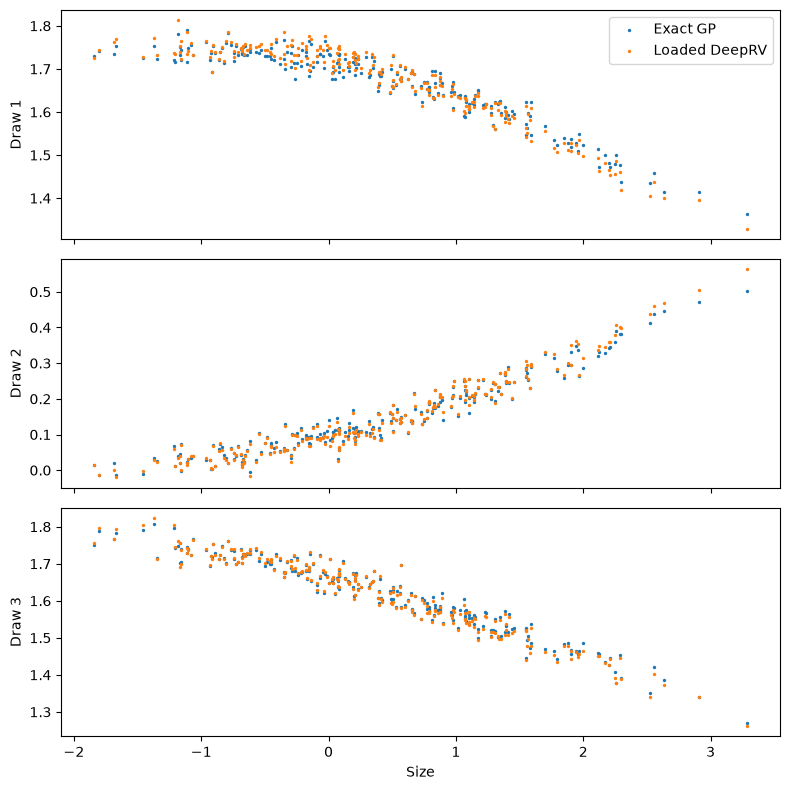

In [19]:
order = np.argsort(np.asarray(s).squeeze())
s_sorted = np.asarray(s).squeeze()[order]
f_true_np = np.asarray(f_true)
f_hat_np = np.asarray(f_hat)
fig, axes = plt.subplots(
    3,
    1,
    figsize=(8, 8),
    sharex=True,
)

for i, ax in enumerate(axes):
    ax.scatter(
        s_sorted,
        f_true_np[i, order],
        label="Exact GP",
        s=2,
    )

    ax.scatter(
        s_sorted,
        f_hat_np[i, order],
        label="Loaded DeepRV",
        s= 2,
    )

    ax.set_ylabel(f"Draw {i + 1}")

axes[0].legend()
axes[-1].set_xlabel("Size")
plt.tight_layout()
plt.show()

In [20]:
def bernoulli_inference_model(s: Array, priors: dict):
    """
    Builds a Bernoulli likelihood inference model for GP and surrogate models
    """
    surrogate_kwargs = {"s": s}

    def bernoulli(surrogate_decoder=None, obs_mask=True, y=None):
        var = numpyro.sample("r", priors["r"], sample_shape=())
        ls = numpyro.sample("ls", priors["ls"], sample_shape=())
        z = numpyro.sample("z", dist.Normal(), sample_shape=(1, s.shape[0])) #z is (1,N) 
        beta = numpyro.sample("beta", priors["beta"], sample_shape=())
        if surrogate_decoder is None:
            K = rbf(s, s, var, ls) + 5e-4 * jnp.eye(s.shape[0])
            L_chol = jnp.linalg.cholesky(K)
            mu = jnp.matmul(L_chol, z[0]) + beta
            mu = numpyro.deterministic("mu", jnp.matmul(L_chol, z[0]))
        else:  # NOTE: whether to use a replacment for the GP
            mu_unit = surrogate_decoder(z, jnp.array([ls]), **surrogate_kwargs).squeeze()
            mu_obs = jnp.sqrt(var) * mu_unit
            mu = numpyro.deterministic(
                "mu",
                mu_obs,
            )
        p = jax.nn.sigmoid(mu + beta)
        with numpyro.handlers.mask(mask=obs_mask):
            numpyro.sample("obs", dist.Bernoulli(probs=p), obs=y)

    return bernoulli        




In [ ]:
def bernoulli_inference_model(s: Array, priors: dict):
    """
    Builds a Bernoulli likelihood inference model for GP and surrogate models
    """
    surrogate_kwargs = {"s": s}

    def bernoulli(surrogate_decoder=None, obs_mask=True, y=None):
        var = numpyro.sample("r", priors["r"], sample_shape=())
        ls = numpyro.sample("ls", priors["ls"], sample_shape=())
        z = numpyro.sample("z", dist.Normal(), sample_shape=(1, s.shape[0])) #z is (1,N) 
        if surrogate_decoder is None:
            K = rbf(s, s, var, ls) + 5e-4 * jnp.eye(s.shape[0])
            L_chol = jnp.linalg.cholesky(K)
            mu = numpyro.deterministic("mu", jnp.matmul(L_chol, z[0]))
        else:  # NOTE: whether to use a replacment for the GP
            mu_unit = surrogate_decoder(z, jnp.array([ls]), **surrogate_kwargs).squeeze()
            mu_obs = jnp.sqrt(var) * mu_unit
            mu = numpyro.deterministic(
                "mu",
                mu_obs,
            )
        p = jax.nn.sigmoid(mu)
        with numpyro.handlers.mask(mask=obs_mask):
            numpyro.sample("obs", dist.Bernoulli(probs=p), obs=y)

    return bernoulli

In [21]:
def poisson_inference_model(s: Array, priors: dict):
    """
    Builds a Poisson likelihood inference model for GP and surrogate models
    """
    surrogate_kwargs = {"s": s}

    def poisson(surrogate_decoder=None, obs_mask=True, y=None):
        var = numpyro.sample("r", priors["r"], sample_shape=())
        ls = numpyro.sample("ls", priors["ls"], sample_shape=())
        z = numpyro.sample("z", dist.Normal(), sample_shape=(1, s.shape[0])) #z is (1,N) 
        beta = numpyro.sample("beta", priors["beta"], sample_shape=())
        if surrogate_decoder is None:
            K = rbf(s, s, var, ls) + 5e-4 * jnp.eye(s.shape[0])
            L_chol = jnp.linalg.cholesky(K)
            mu = numpyro.deterministic("mu", jnp.matmul(L_chol, z[0]))
        else:  # NOTE: whether to use a replacment for the GP
            mu_unit = surrogate_decoder(z, jnp.array([ls]), **surrogate_kwargs).squeeze()
            mu_obs = jnp.sqrt(var) * mu_unit
            mu = numpyro.deterministic(
                "mu",
                mu_obs,
            )
        lambda_ = jnp.exp(mu + beta)
        with numpyro.handlers.mask(mask=obs_mask):
            numpyro.sample("obs", dist.Poisson(rate=lambda_), obs=y)

    return poisson

In [22]:
def gaussian_inference_model(s: Array, priors: dict):
    """
    Builds a Gaussian likelihood inference model for GP and surrogate models
    """
    surrogate_kwargs = {"s": s}

    def gaussian(surrogate_decoder=None, obs_mask=True, y=None):
        var = numpyro.sample("r", priors["r"], sample_shape=())
        ls = numpyro.sample("ls", priors["ls"], sample_shape=())
        z = numpyro.sample("z", dist.Normal(), sample_shape=(1, s.shape[0]))
        obs_noise = numpyro.sample("obs_noise", priors["obs_noise"])
        beta = numpyro.sample("beta", priors["beta"], sample_shape=())
        if surrogate_decoder is None:
            K = rbf(s, s, var, ls) + 5e-4 * jnp.eye(s.shape[0])
            L_chol = jnp.linalg.cholesky(K)
            mu = numpyro.deterministic("mu", jnp.matmul(L_chol, z[0]))
        else:  # NOTE: whether to use a replacment for the GP
            mu_unit = surrogate_decoder(z, jnp.array([ls]), **surrogate_kwargs).squeeze()
            mu_obs = jnp.sqrt(var) * mu_unit
            mu = numpyro.deterministic(
                "mu",
                mu_obs,
            )
            mean = mu + beta
        with numpyro.handlers.mask(mask=obs_mask):
            numpyro.sample("obs", dist.Normal(loc=mean, scale=obs_noise), obs=y)

    return gaussian


In [17]:
def gaussian_inference_model(s: Array, priors: dict):
    """
    Builds a Gaussian likelihood inference model for GP and surrogate models
    """
    surrogate_kwargs = {"s": s}

    def gaussian(surrogate_decoder=None, obs_mask=True, y=None):
        var = numpyro.sample("r", priors["r"], sample_shape=())
        ls = numpyro.sample("ls", priors["ls"], sample_shape=())
        z = numpyro.sample("z", dist.Normal(), sample_shape=(1, s.shape[0]))
        obs_noise = numpyro.sample("obs_noise", priors["obs_noise"])

        if surrogate_decoder is None:
            K = rbf(s, s, var, ls) + 5e-4 * jnp.eye(s.shape[0])
            L_chol = jnp.linalg.cholesky(K)
            mu = numpyro.deterministic("mu", jnp.matmul(L_chol, z[0]))
        else:  # NOTE: whether to use a replacment for the GP
            mu_unit = surrogate_decoder(z, jnp.array([ls]), **surrogate_kwargs).squeeze()
            mu_obs = jnp.sqrt(var) * mu_unit
            mu = numpyro.deterministic(
                "mu",
                mu_obs,
            )
        with numpyro.handlers.mask(mask=obs_mask):
            numpyro.sample("obs", dist.Normal(loc=mu, scale=obs_noise), obs=y)

    return gaussian


In [25]:
def inference_comparison(rng, s, y, priors, likelihood_model, surrogate_decoder, obs_mask=True):
    rng_gp, rng_deeprv = random.split(rng)
    gp_samples, gp_mcmc, gp_posterior, gp_timings = run_gp_inference(rng_gp, s, y, priors, likelihood_model, obs_mask)
    deeprv_samples, deeprv_mcmc, deeprv_posterior, deeprv_timings = run_deeprv_inference(rng_deeprv, s, y, priors, surrogate_decoder, likelihood_model, obs_mask)

    # TO ADD: Print Timings
    return {
        "gp": {
            "samples": gp_samples,
            "mcmc": gp_mcmc,
            "posterior": gp_posterior,
            "timings": gp_timings,
        },
        "deeprv": {
          "samples": deeprv_samples,
            "mcmc": deeprv_mcmc,
           "posterior": deeprv_posterior,
            "timings": deeprv_timings,
        },
    }

In [26]:
rng = random.key(1)
rng_surv, rng_repr, rng_seed, rng_growth = random.split(rng, 4)

In [27]:
survival_results = inference_comparison(
    rng_surv, 
    s_surv, 
    y_surv.squeeze(), 
    survival_priors, 
    bernoulli_inference_model, 
    models["survival"]["decoder"],
    )

/Users/keynestay/Desktop/dl4bi/deeprv_utils.py:39: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(nuts, num_chains=2, num_samples=4_000, num_warmup=2_000,)
sample: 100%|██████████| 6000/6000 [02:46<00:00, 36.06it/s, 31 steps of size 1.39e-01. acc. prob=0.94]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
      beta     -0.22      0.64     -0.21     -1.32      0.79   7323.93      1.00
        ls      1.33      0.48      1.27      0.57      2.06   5782.86      1.00
         r      1.12      0.54      1.03      0.31      1.94  11653.03      1.00
    z[0,0]      0.81      0.67      0.80     -0.30      1.91   8118.21      1.00
    z[0,1]     -1.36      0.61     -1.34     -2.36     -0.38   6819.66      1.00
    z[0,2]      0.25      0.83      0.29     -1.04      1.68   9050.25      1.00
    z[0,3]     -0.77      0.81     -0.81     -2.08      0.59   9534.42      1.00
    z[0,4]     -0.06      1.01     -0.05     -1.81      1.50  19816.35      1.00
    z[0,5]      0.16      0.99      0.17     -1.47      1.77  17541.73      1.00
    z[0,6]      0.04      0.94      0.06     -1.55      1.54  13482.12      1.00
    z[0,7]      0.00      0.98      0.01     -1.54      1.67  21951.98      1.00
    z[0,8]      0.13      0

/Users/keynestay/Desktop/dl4bi/deeprv_utils.py:39: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(nuts, num_chains=2, num_samples=4_000, num_warmup=2_000,)
sample: 100%|██████████| 6000/6000 [05:16<00:00, 18.97it/s, 31 steps of size 1.36e-01. acc. prob=0.94] 



                mean       std    median      5.0%     95.0%     n_eff     r_hat
      beta     -0.22      0.63     -0.22     -1.22      0.87   6208.25      1.00
        ls      1.33      0.48      1.27      0.60      2.10   5488.44      1.00
         r      1.11      0.52      1.02      0.31      1.90  11328.18      1.00
    z[0,0]      0.82      0.68      0.81     -0.33      1.90   6979.28      1.00
    z[0,1]     -1.35      0.61     -1.33     -2.38     -0.39   5785.65      1.00
    z[0,2]      0.25      0.82      0.26     -1.12      1.55   7438.67      1.00
    z[0,3]     -0.76      0.82     -0.79     -2.20      0.49   8315.37      1.00
    z[0,4]     -0.05      0.99     -0.05     -1.72      1.55  17843.40      1.00
    z[0,5]      0.15      0.99      0.15     -1.42      1.85  16712.37      1.00
    z[0,6]      0.07      0.95      0.08     -1.48      1.67  14305.11      1.00
    z[0,7]      0.01      1.00      0.01     -1.65      1.64  19211.60      1.00
    z[0,8]      0.14      0

In [21]:
repr_results = inference_comparison(
    rng_repr, 
    s_repr, 
    y_repr.squeeze(), 
    priors, 
    bernoulli_inference_model, 
    models["reproduction"]["decoder"]
    )

/Users/keynestay/Desktop/dl4bi/deeprv_utils.py:39: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(nuts, num_chains=2, num_samples=4_000, num_warmup=2_000,)
sample: 100%|██████████| 6000/6000 [01:59<00:00, 50.42it/s, 31 steps of size 1.73e-01. acc. prob=0.91]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
        ls      1.79      0.64      1.71      0.76      2.74   5650.95      1.00
         r      9.36      3.01      9.08      4.35     13.99  14296.08      1.00
    z[0,0]     -2.06      0.48     -2.00     -2.82     -1.31   9472.07      1.00
    z[0,1]     -1.42      0.67     -1.38     -2.49     -0.29   8635.07      1.00
    z[0,2]      0.50      0.96      0.51     -1.16      1.98   9317.40      1.00
    z[0,3]     -0.76      0.96     -0.78     -2.41      0.76  10862.56      1.00
    z[0,4]     -0.14      1.00     -0.15     -1.72      1.57  19897.22      1.00
    z[0,5]     -0.07      0.98     -0.06     -1.70      1.51  20311.94      1.00
    z[0,6]      0.71      0.89      0.72     -0.75      2.17  12571.38      1.00
    z[0,7]     -0.01      1.00     -0.00     -1.59      1.68  21044.83      1.00
    z[0,8]     -0.22      1.00     -0.22     -1.82      1.42  20960.47      1.00
    z[0,9]      0.02      0

/Users/keynestay/Desktop/dl4bi/deeprv_utils.py:39: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(nuts, num_chains=2, num_samples=4_000, num_warmup=2_000,)
sample: 100%|██████████| 6000/6000 [06:42<00:00, 14.90it/s, 31 steps of size 1.72e-01. acc. prob=0.91] 



                mean       std    median      5.0%     95.0%     n_eff     r_hat
        ls      1.76      0.62      1.69      0.77      2.64   5485.17      1.00
         r      9.38      3.01      9.12      4.66     14.34  14865.82      1.00
    z[0,0]     -2.07      0.50     -2.02     -2.86     -1.28  10994.62      1.00
    z[0,1]     -1.40      0.68     -1.35     -2.54     -0.31   9211.28      1.00
    z[0,2]      0.40      0.94      0.40     -1.05      2.03  10892.73      1.00
    z[0,3]     -0.55      1.05     -0.61     -2.22      1.24   8968.79      1.00
    z[0,4]     -0.20      1.01     -0.18     -1.87      1.44  18850.80      1.00
    z[0,5]     -0.01      0.98     -0.01     -1.58      1.60  19129.14      1.00
    z[0,6]      0.80      0.87      0.81     -0.64      2.18  16739.06      1.00
    z[0,7]      0.03      0.98      0.04     -1.58      1.58  19199.87      1.00
    z[0,8]     -0.21      0.97     -0.22     -1.86      1.28  18386.13      1.00
    z[0,9]     -0.01      1

In [25]:
seed_results = inference_comparison(
    rng_seed, 
    s_seed, 
    y_seed.squeeze(), 
    priors, 
    poisson_inference_model, 
    models["seed"]["decoder"]
    )

/Users/keynestay/Desktop/dl4bi/deeprv_utils.py:39: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(nuts, num_chains=2, num_samples=4_000, num_warmup=2_000,)
sample: 100%|██████████| 6000/6000 [00:26<00:00, 226.01it/s, 255 steps of size 7.99e-03. acc. prob=0.95]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
      beta      7.58      0.46      7.58      6.80      8.32   4694.22      1.00
        ls      0.66      0.19      0.64      0.38      0.92   1779.68      1.00
         r      1.02      0.42      0.93      0.39      1.61   5418.54      1.00
    z[0,0]     -0.65      0.51     -0.63     -1.48      0.18   4597.02      1.00
    z[0,1]     -1.77      0.40     -1.74     -2.40     -1.13   1926.16      1.00
    z[0,2]     -0.78      0.73     -0.80     -1.97      0.41   8174.44      1.00
    z[0,3]     -0.10      0.81     -0.10     -1.42      1.25  10208.59      1.00
    z[0,4]      0.08      0.75      0.07     -1.15      1.32   9215.80      1.00
    z[0,5]     -0.20      0.71     -0.20     -1.34      0.98   8358.33      1.00
    z[0,6]      2.13      0.52      2.12      1.25      2.95   4837.50      1.00
    z[0,7]     -0.71      0.78     -0.64     -1.99      0.52   2876.26      1.00
    z[0,8]     -0.19      0

/Users/keynestay/Desktop/dl4bi/deeprv_utils.py:39: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(nuts, num_chains=2, num_samples=4_000, num_warmup=2_000,)
sample: 100%|██████████| 6000/6000 [05:21<00:00, 18.64it/s, 511 steps of size 7.71e-03. acc. prob=0.96] 



                mean       std    median      5.0%     95.0%     n_eff     r_hat
      beta      7.59      0.46      7.61      6.84      8.35   3446.27      1.00
        ls      0.64      0.18      0.61      0.38      0.88   1517.87      1.00
         r      0.94      0.38      0.86      0.38      1.47   3386.74      1.00
    z[0,0]     -0.69      0.52     -0.70     -1.55      0.19   3480.07      1.00
    z[0,1]     -1.78      0.36     -1.76     -2.33     -1.18   2775.37      1.00
    z[0,2]     -0.66      0.71     -0.66     -1.89      0.45   7674.23      1.00
    z[0,3]     -0.08      0.83     -0.08     -1.45      1.31   8585.38      1.00
    z[0,4]      0.02      0.76      0.02     -1.21      1.28   7235.72      1.00
    z[0,5]     -0.20      0.68     -0.20     -1.32      0.92   7341.46      1.00
    z[0,6]      2.16      0.54      2.14      1.29      3.04   3656.34      1.00
    z[0,7]     -0.70      0.76     -0.65     -1.95      0.53   3287.04      1.00
    z[0,8]      0.11      0

In [29]:
growth_results = inference_comparison(
    rng_growth, 
    s_growth, 
    y_growth.squeeze(), 
    priors, 
    gaussian_inference_model, 
    models["growth"]["decoder"]
    )

/Users/keynestay/Desktop/dl4bi/deeprv_utils.py:39: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(nuts, num_chains=2, num_samples=4_000, num_warmup=2_000,)
sample: 100%|██████████| 6000/6000 [01:04<00:00, 93.18it/s, 63 steps of size 7.95e-02. acc. prob=0.94] 



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
         ls      4.88      1.87      4.61      1.98      7.73   7439.79      1.00
  obs_noise      0.73      0.05      0.72      0.64      0.80  18413.36      1.00
          r      5.24      2.68      4.79      1.30      9.21   9625.32      1.00
     z[0,0]      0.83      0.25      0.78      0.46      1.19   6060.22      1.00
     z[0,1]      1.40      0.52      1.34      0.59      2.22   9177.79      1.00
     z[0,2]      0.57      0.90      0.57     -0.90      2.03  15209.02      1.00
     z[0,3]     -0.07      0.96     -0.07     -1.66      1.51  20022.84      1.00
     z[0,4]      0.00      1.00      0.00     -1.68      1.60  20923.08      1.00
     z[0,5]     -0.03      1.01     -0.03     -1.73      1.58  19239.59      1.00
     z[0,6]     -0.03      0.95     -0.03     -1.56      1.57  18785.79      1.00
     z[0,7]      0.04      0.97      0.04     -1.56      1.60  17237.72      1.00
     z[0,8]    

/Users/keynestay/Desktop/dl4bi/deeprv_utils.py:39: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(nuts, num_chains=2, num_samples=4_000, num_warmup=2_000,)
sample: 100%|██████████| 6000/6000 [04:29<00:00, 22.23it/s, 63 steps of size 8.49e-02. acc. prob=0.94] 



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
         ls      4.92      1.89      4.63      2.01      7.83   8208.28      1.00
  obs_noise      0.73      0.05      0.72      0.64      0.81  16441.92      1.00
          r      5.27      2.69      4.86      1.26      9.32   9359.32      1.00
     z[0,0]      0.83      0.25      0.77      0.46      1.20   5555.82      1.00
     z[0,1]      1.26      0.62      1.20      0.24      2.26  10303.96      1.00
     z[0,2]      0.82      0.90      0.82     -0.61      2.33  13764.99      1.00
     z[0,3]     -0.02      0.99     -0.02     -1.61      1.61  16653.12      1.00
     z[0,4]     -0.02      0.98     -0.02     -1.60      1.61  16999.57      1.00
     z[0,5]      0.06      0.99      0.06     -1.49      1.73  17801.16      1.00
     z[0,6]     -0.11      0.97     -0.12     -1.75      1.42  17102.32      1.00
     z[0,7]      0.04      0.96      0.03     -1.48      1.66  19124.66      1.00
     z[0,8]    

In [28]:
# Recruitment Probability
n_recruits = int(((sim_data["age"] == 0) & sim_data["z"].notna()).sum())
total_seeds = int(np.nansum(sim_data["n_seeds"]))

if total_seeds == 0:
    raise ValueError("Recruitment probability cannot be estimated because total seed production is zero.")

if n_recruits > total_seeds:
    raise ValueError("The number of recruits cannot exceed the number of seeds.")

p_recruit_est = n_recruits / total_seeds

print("New recruits:", n_recruits)
print("Total seeds:", total_seeds)
print("Recruitment probability:", p_recruit_est)

New recruits: 154
Total seeds: 27763
Recruitment probability: 0.005546950977920254


In [29]:
# Recruit Density
from scipy import stats

recruit_sizes = sim_data.loc[(sim_data["age"] == 0) & sim_data["z"].notna(), "z"].to_numpy()
recruit_mean_est, recruit_sd_est = stats.norm.fit(recruit_sizes)

print("Recruitment mean:", recruit_mean_est)
print("Recruitment SD:", recruit_sd_est)

Recruitment mean: -0.1109900526332267
Recruitment SD: 0.7390069211981969


In [31]:
inference_results = {
    "survival": survival_results,
    "reproduction": repr_results,
    "seed": seed_results,
    "growth": growth_results,
}

observed_locations = {
    "survival": s_surv,
    "reproduction": s_repr,
    "seed": s_seed,
    "growth": s_growth,
}

recruitment = {
    "probability": p_recruit_est,
    "mean": recruit_mean_est,
    "sd": recruit_sd_est,
}

NameError: name 'repr_results' is not defined

In [ ]:
def save_ipm_inputs(path, inference_results, observed_locations, recruitment, method="gp"):
    parameter_names = ("mu", "r", "ls", "obs_noise", "beta")
    arrays = {}

    for vital_rate, results in inference_results.items():
        samples = results[method]["samples"]

        for parameter in parameter_names:
            if parameter in samples:
                arrays[f"{vital_rate}__{parameter}"] = np.asarray(jax.device_get(samples[parameter]))

        arrays[f"{vital_rate}__s_obs"] = np.asarray(jax.device_get(observed_locations[vital_rate]))

    arrays["recruitment__probability"] = np.asarray(recruitment["probability"])
    arrays["recruitment__mean"] = np.asarray(recruitment["mean"])
    arrays["recruitment__sd"] = np.asarray(recruitment["sd"])
    arrays["gp__jitter"] = np.asarray(5e-4)

    np.savez_compressed(path, **arrays)

In [ ]:
save_ipm_inputs(
    "results/N_250/gp_posterior_samples.npz", 
    inference_results, 
    observed_locations, 
    recruitment
    )

save_ipm_inputs(
    "results/N_250/deeprv_posterior_samples.npz", 
    inference_results, 
    observed_locations, 
    recruitment, 
    method = "deeprv"
    )